**DATASET**

In [71]:
import os

# Path dataset
DATA_DIR = "data"

train_dir = os.path.join(DATA_DIR, "train")
test_dir  = os.path.join(DATA_DIR, "test")

In [72]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import torch
import torchvision

import albumentations as A
from albumentations.pytorch import ToTensorV2

**Cek Folder**

In [73]:
import os

ROOT = "BDC 2026"

print(os.listdir(ROOT))
TRAIN_DIR = os.path.join(ROOT,"train")
TEST_DIR = os.path.join(ROOT,"test")

print(os.listdir(TRAIN_DIR))

['submission.csv', 'test', 'train']
['0_Recyclable', '1_Electronic', '2_Organic']


In [74]:
classes = os.listdir(TRAIN_DIR)

for c in classes:

    folder = os.path.join(TRAIN_DIR,c)

    print(c,len(os.listdir(folder)))

0_Recyclable 9547
1_Electronic 3950
2_Organic 11457


**Visualisasi Penyeberan Data**

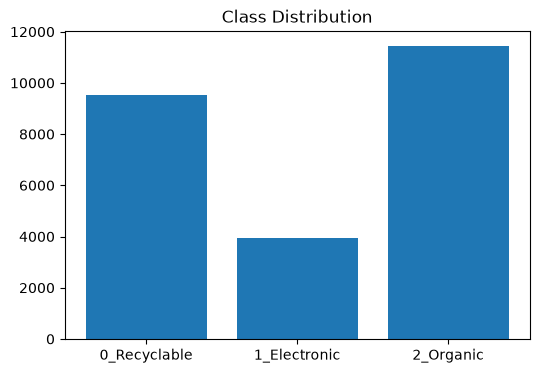

In [75]:
counts = {}

for c in classes:

    counts[c] = len(os.listdir(os.path.join(TRAIN_DIR,c)))

plt.figure(figsize=(6,4))

plt.bar(counts.keys(),counts.values())

plt.title("Class Distribution")

plt.show()

**Sample Gambar**

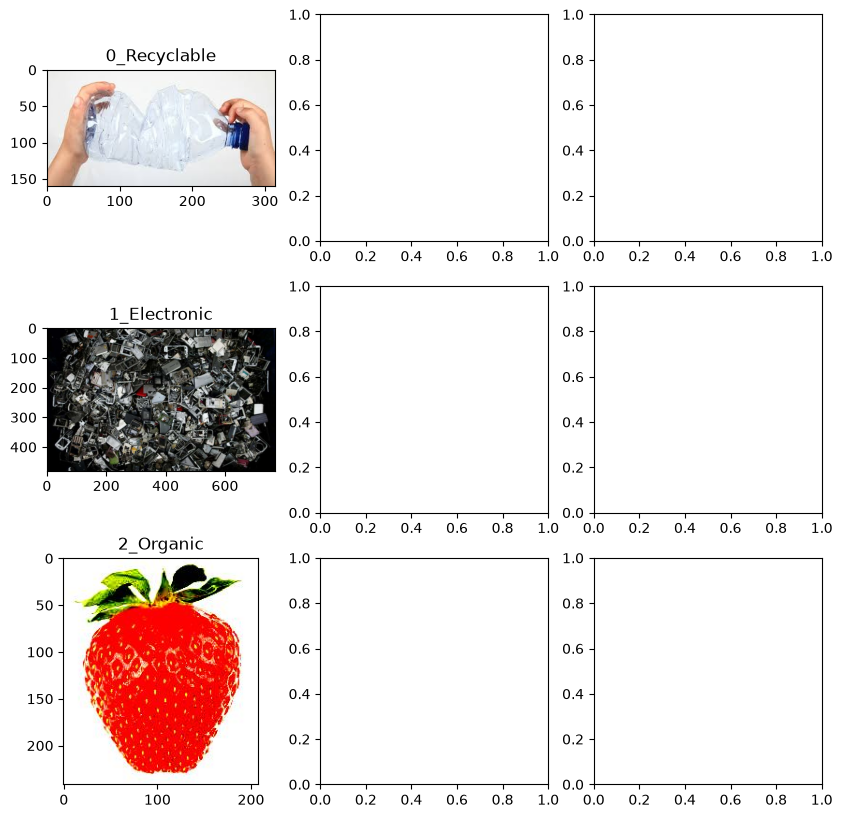

In [76]:
fig,ax = plt.subplots(3,3,figsize=(10,10))

for i,c in enumerate(classes):

    folder = os.path.join(TRAIN_DIR,c)

    img = os.listdir(folder)[0]

    path = os.path.join(folder,img)

    image = Image.open(path)

    ax[i,0].imshow(image)

    ax[i,0].set_title(c)

plt.show()

Ukuran Gambar

In [77]:
sizes=[]

for c in classes:

    folder=os.path.join(TRAIN_DIR,c)

    for img in os.listdir(folder):

        path=os.path.join(folder,img)

        image=Image.open(path)

        sizes.append(image.size)
        print(Counter(sizes).most_common(10))
        break

[((314, 160), 1)]
[((314, 160), 1), ((768, 480), 1)]
[((314, 160), 1), ((768, 480), 1), ((208, 242), 1)]


Corrupt Image


In [78]:
broken=[]

for c in classes:

    folder=os.path.join(TRAIN_DIR,c)

    for img in os.listdir(folder):

        try:

            Image.open(os.path.join(folder,img))

        except:

            broken.append(img)

print(len(broken))

0


In [79]:
test_images = sorted(os.listdir(TEST_DIR))

Data Augmentation

In [80]:
train_transform = A.Compose([

    A.Resize(224,224),

    A.HorizontalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=20,
        p=0.5
    ),

    A.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),

    ToTensorV2()

])

C:\Users\MyPC PRO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Dataframe


In [81]:
images=[]
labels=[]

for c in classes:

    folder=os.path.join(TRAIN_DIR,c)

    for img in os.listdir(folder):

        images.append(os.path.join(folder,img))

        labels.append(c)

df=pd.DataFrame({

    "image":images,

    "label":labels

})

df.head()

,image,label
0,BDC 2026\train\0_Recyclable\R_1.jpg,0_Recyclable
1,BDC 2026\train\0_Recyclable\R_10.jpg,0_Recyclable
2,BDC 2026\train\0_Recyclable\R_100.jpg,0_Recyclable
3,BDC 2026\train\0_Recyclable\R_1000.jpg,0_Recyclable
4,BDC 2026\train\0_Recyclable\R_1001.jpg,0_Recyclable


Encode


In [82]:
from sklearn.preprocessing import LabelEncoder

encoder=LabelEncoder()

df["target"]=encoder.fit_transform(df["label"])

df.head()

,image,label,target
0,BDC 2026\train\0_Recyclable\R_1.jpg,0_Recyclable,0
1,BDC 2026\train\0_Recyclable\R_10.jpg,0_Recyclable,0
2,BDC 2026\train\0_Recyclable\R_100.jpg,0_Recyclable,0
3,BDC 2026\train\0_Recyclable\R_1000.jpg,0_Recyclable,0
4,BDC 2026\train\0_Recyclable\R_1001.jpg,0_Recyclable,0


Split

In [83]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, valid_idx) in enumerate(
    skf.split(df, df["target"])
):

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)

    print(f"Fold {fold}")
    print(train_df.shape)
    print(valid_df.shape)


Fold 0
(19963, 3)
(4991, 3)
Fold 1
(19963, 3)
(4991, 3)
Fold 2
(19963, 3)
(4991, 3)
Fold 3
(19963, 3)
(4991, 3)
Fold 4
(19964, 3)
(4990, 3)


Dataset


In [84]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="BDC 2026/train",
    transform=train_transform
)
from torch.utils.data import Dataset
import cv2

class WasteDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["image"]
        label = row["target"]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:

            image = self.transform(image=image)["image"]

        return image, label

In [85]:
valid_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),
    ToTensorV2()
])

train_dataset = WasteDataset(

    dataframe=train_df,

    transform=train_transform

)

valid_dataset = WasteDataset(

    dataframe=valid_df,

    transform=valid_transform

)

In [86]:
from torch.utils.data import DataLoader
train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True,

    num_workers=0,

    pin_memory=False

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=16,

    shuffle=False,

    num_workers=0,

    pin_memory=False

)

Model

In [87]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [88]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3060


ViT-B/16 SigLIP2

In [89]:
import timm
import torch.nn as nn
# Model

model = timm.create_model(
    "vit_base_patch16_siglip_224.v2_webli",
    pretrained=True,
    num_classes=3
)

model = model.to(device)

In [90]:
print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [91]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)
outputs = model(images)

print(outputs.shape)

torch.Size([16, 3])


Baseline

In [92]:
#==================================================
# Loss Function
#==================================================
class_counts = torch.tensor([9999.0, 3961.0, 12567.0])  # urutan target 0,1,2 = Recyclable, Electronic, Organic
weights = class_counts.sum() / (len(class_counts) * class_counts)
weights = weights.to(device)
print("Class weights:", weights)

criterion = nn.CrossEntropyLoss(weight=weights)
#==================================================
# Optimizer
#==================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

#==================================================
# Scheduler
#==================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

Class weights: tensor([0.8843, 2.2323, 0.7036], device='cuda:0')


Training

In [93]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0

    preds = []
    labels = []

    progress = tqdm(loader)

    for images, target in progress:

        images = images.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, target)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        prediction = torch.argmax(outputs, dim=1)

        preds.extend(prediction.cpu().numpy())

        labels.extend(target.cpu().numpy())

        progress.set_description(
            f"Loss {loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader)

    epoch_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    return epoch_loss, epoch_f1

Validation

In [94]:
@torch.no_grad()

def valid_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    preds = []
    labels = []

    for images,target in loader:

        images = images.to(device)
        target = target.to(device)

        outputs = model(images)

        loss = criterion(outputs,target)

        running_loss += loss.item()

        prediction = torch.argmax(outputs,1)

        preds.extend(
            prediction.cpu().numpy()
        )

        labels.extend(
            target.cpu().numpy()
        )

    epoch_loss = running_loss/len(loader)

    epoch_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    return epoch_loss,epoch_f1

Loop Training

In [95]:
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [96]:
EPOCHS = 10

best_f1 = 0
for epoch in range(EPOCHS):

    train_loss, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    valid_loss, valid_f1 = valid_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    scheduler.step()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train F1   : {train_f1:.4f}")

    print(f"Valid Loss : {valid_loss:.4f}")

    print(f"Valid F1   : {valid_f1:.4f}")

    if valid_f1 > best_f1:
        best_f1 = valid_f1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best Model Saved (Valid F1: {best_f1:.4f})")

    print(f"\nTraining selesai. Best Valid F1: {best_f1:.4f}")

Loss 0.0749: 100%|██████████| 1248/1248 [07:42<00:00,  2.70it/s]



Epoch 1/10
Train Loss : 0.1536
Train F1   : 0.9407
Valid Loss : 0.0791
Valid F1   : 0.9746
Best Model Saved (Valid F1: 0.9746)

Training selesai. Best Valid F1: 0.9746


Loss 0.1763: 100%|██████████| 1248/1248 [07:43<00:00,  2.69it/s]



Epoch 2/10
Train Loss : 0.0947
Train F1   : 0.9620
Valid Loss : 0.0709
Valid F1   : 0.9740

Training selesai. Best Valid F1: 0.9746


Loss 0.1122: 100%|██████████| 1248/1248 [07:44<00:00,  2.69it/s]


...


Epoch 8/10
Train Loss : 0.0082
Train F1   : 0.9969
Valid Loss : 0.0466
Valid F1   : 0.9853

Training selesai. Best Valid F1: 0.9854


Loss 0.0000: 100%|██████████| 1248/1248 [07:41<00:00,  2.70it/s]



Epoch 9/10
Train Loss : 0.0041
Train F1   : 0.9986
Valid Loss : 0.0406
Valid F1   : 0.9882
Best Model Saved (Valid F1: 0.9882)

Training selesai. Best Valid F1: 0.9882


Loss 0.0000: 100%|██████████| 1248/1248 [07:40<00:00,  2.71it/s]



Epoch 10/10
Train Loss : 0.0023
Train F1   : 0.9991
Valid Loss : 0.0411
Valid F1   : 0.9879

Training selesai. Best Valid F1: 0.9882


# **Inference pada DataTest**

DataFrame Test

In [97]:
import pandas as pd
import os

test_images = sorted(
    os.listdir(TEST_DIR),
    key=lambda x: int(''.join(filter(str.isdigit, x)))
)

test_df = pd.DataFrame({
    "image": test_images
})

# Kolom id eksplisit, dipakai nanti untuk mapping yang aman (bukan
# hanya mengandalkan urutan baris)
test_df["id"] = test_df["image"].apply(
    lambda x: int(''.join(filter(str.isdigit, x)))
)

test_df.head()


,image,id
0,1.jpg,1
1,2.jpg,2
2,3.jpg,3
3,4.jpg,4
4,5.jpg,5


Test Dataset


In [98]:
from torch.utils.data import Dataset
import cv2

class TestDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):

        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image_name = self.df.loc[idx, "image"]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:

            image = self.transform(
                image=image
            )["image"]

        return image, image_name

test_dataset = TestDataset(
    dataframe=test_df,
    image_dir=TEST_DIR,
    transform=valid_transform
)

Test DataLoader

In [99]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Load Model

In [100]:
import torch
import timm

NUM_CLASSES = 3

model = timm.create_model(
    "vit_base_patch16_siglip_224.v2_webli",
    pretrained=False,
    num_classes=NUM_CLASSES
)

model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model.to(device)
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

Prediksi

In [101]:
predictions = []

with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())

In [102]:
print(predictions[:10])

[np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(1), np.int64(2)]


Submission

In [103]:
pred_map = dict(zip(test_df["id"], predictions))

submission = pd.read_csv("BDC 2026/submission.csv")
submission["predicted"] = submission["id"].map(pred_map)

# Pastikan tidak ada id yang gagal ter-mapping (harus 0)
assert submission["predicted"].isna().sum() == 0, "Ada id yang tidak ter-mapping, cek ulang!"

submission["predicted"] = submission["predicted"].astype(int)

submission.to_csv(
    "submission_siglip_vit_p3.csv",
    index=False
)

submission.head()

,id,predicted
0,1,2
1,2,2
2,3,2
3,4,1
4,5,0


In [104]:
print(submission.head(10))
print()
print(submission.tail(10))
print()
print(submission["predicted"].value_counts())

   id  predicted
0   1          2
1   2          2
2   3          2
3   4          1
4   5          0
5   6          0
6   7          2
7   8          0
8   9          1
9  10          2

        id  predicted
1448  1449          2
1449  1450          2
1450  1451          0
1451  1452          1
1452  1453          1
1453  1454          2
1454  1455          2
1455  1456          0
1456  1457          2
1457  1458          0

predicted
2    732
0    528
1    198
Name: count, dtype: int64


Cek Model

In [105]:
from sklearn.metrics import classification_report

preds = []
labels = []

model.eval()

with torch.no_grad():

    for images, target in valid_loader:

        images = images.to(device)

        outputs = model(images)

        pred = torch.argmax(outputs,1)

        preds.extend(pred.cpu().numpy())

        labels.extend(target.numpy())

print(classification_report(labels,preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1909
           1       1.00      0.98      0.99       790
           2       0.99      0.99      0.99      2291

    accuracy                           0.99      4990
   macro avg       0.99      0.99      0.99      4990
weighted avg       0.99      0.99      0.99      4990

